In [79]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

df = pd.read_csv("result.csv")
works_for_ents = df.groupby("entity")["source"].nunique()

In [81]:
df["source"].nunique()

22

### Самая частая сущность

In [82]:
works_for_ents[works_for_ents == works_for_ents.max()]

entity
Пушкин, Александр Сергеевич    19
Name: source, dtype: int64

In [83]:
years = {
    "Жизнь насекомых": 1993,
    "Чапаев и пустота": 1996,
    "Желтая стрела": 1993,
    "Омон Ра": 1992, 
    "Generation «П»": 1999,
    "Священная книга оборотня": 2004,
    "Empire V": 2006,
    "t": 2009,
    "Ананасная вода для прекрасной дамы": 2010,
    "S.N.U.F.F.": 2011,
    "Бэтман Аполло": 2013,
    "Любовь к трем цукербринам": 2014, 
    "Смотритель": 2015, 
    "Лампа_Мафусаила,_или_Крайняя_битва_чекистов_с_масонами_": 2016,
    "iPhuck 10": 2017,
    "Искусство легких касаний": 2019,
    "Непобедимое солнце": 2020,
    "TRANSHUMANISM INC": 2021,
    "KGBT+ (КГБТ+)": 2022,
    "Путешествие в Элевсин": 2023, 
    "Круть": 2024,
    "Македонская_критика_французской_мысли": 2003,
    "Числа": 2003,
    "A Sinistra  А Синистра  Левый Путь": 2023,
    "Возвращение Синей Бороды": 2026,
    "Зал поющих кариатид" : 2008
}

In [84]:
df["year"] = df["source"].map(years)

In [85]:
import ast

df["activities"] = df["activities"].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x
)

### Количество современников по годам

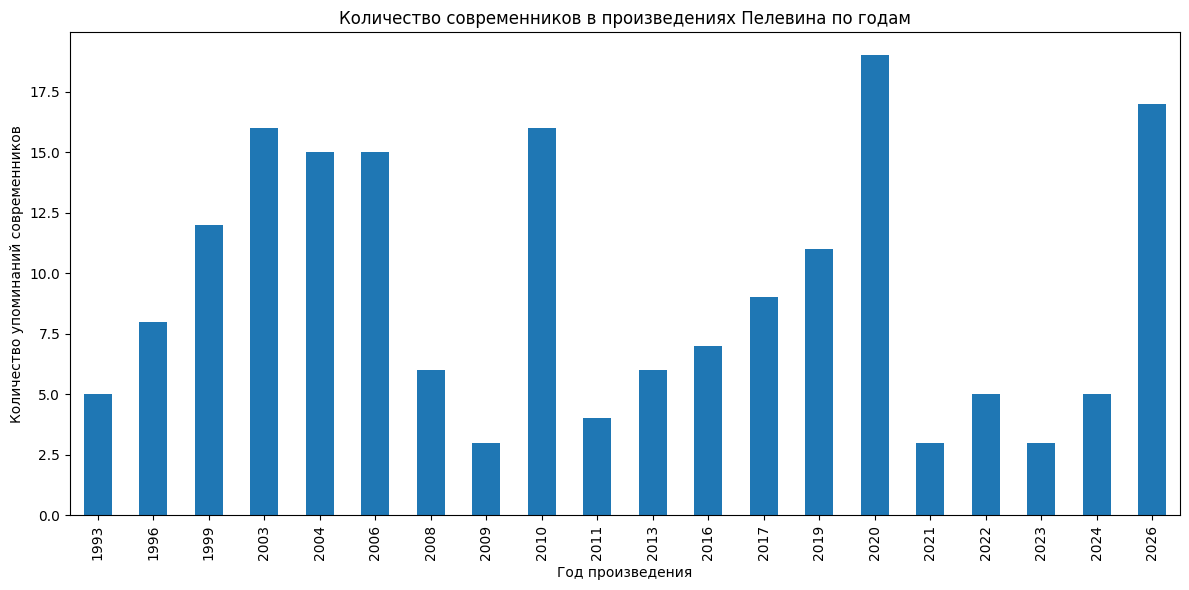

In [86]:
res = df[
    (df["birth_year"] >= 1900) &
    (df["death_year"].isna()) 
]

year_counts = res.groupby("year").size().sort_index()

plt.figure(figsize=(12, 6))
year_counts.plot(kind="bar")
plt.xlabel("Год произведения")
plt.ylabel("Количество упоминаний современников")
plt.title("Количество современников в произведениях Пелевина по годам")
plt.tight_layout()
plt.show()

### Современники vs люди родившееся до 1900

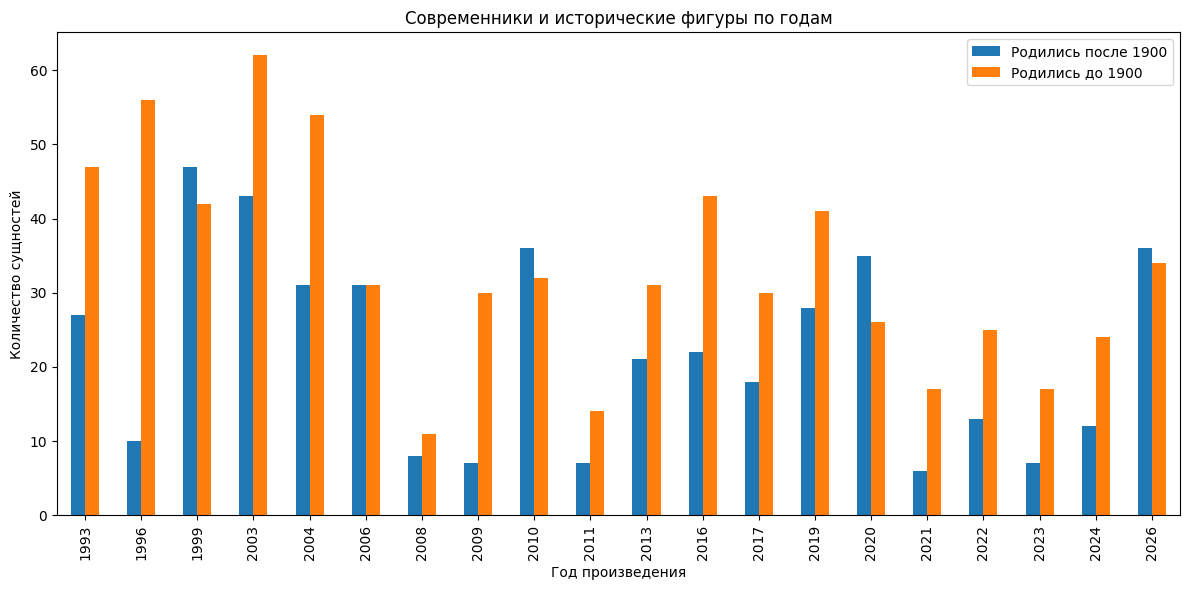

In [87]:
a = df[(df["birth_year"] >= 1900)]
b = df[(df["birth_year"] <= 1900)]

count_a = a.groupby("year").size().sort_index()
count_b = b.groupby("year").size().sort_index()

plot_df = pd.concat(
    [count_a, count_b],
    axis=1
)

plot_df.columns = [
    "Родились после 1900",
    "Родились до 1900"
]

plot_df = plot_df.fillna(0)

plot_df.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.xlabel("Год произведения")
plt.ylabel("Количество сущностей")
plt.title("Современники и исторические фигуры по годам")
plt.tight_layout()
plt.show()

### Количество сущностей по годам

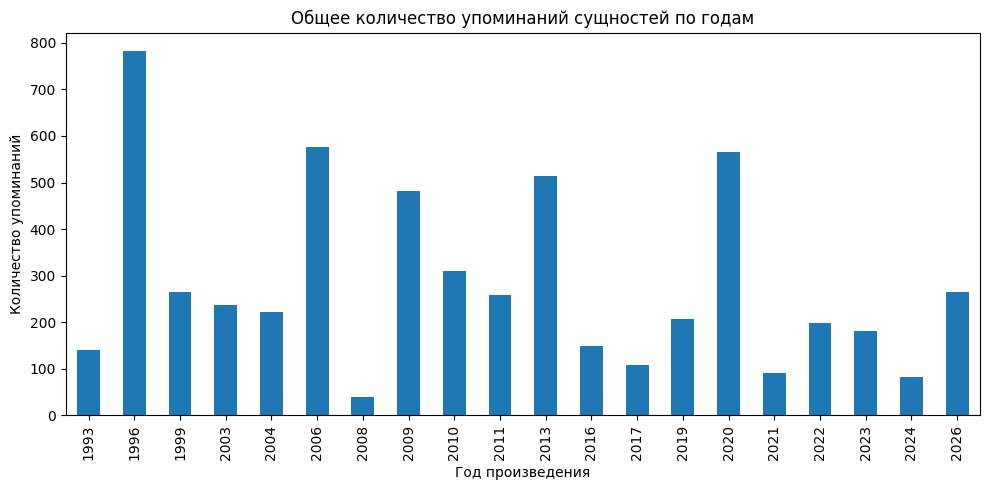

In [88]:
df["count"] = df["count"].astype(int)

mentions_by_year = (
    df.groupby("year")["count"]
      .sum()
      .sort_index()
)

plt.figure(figsize=(10, 5))

mentions_by_year.plot(kind="bar")

plt.xlabel("Год произведения")
plt.ylabel("Количество упоминаний")
plt.title("Общее количество упоминаний сущностей по годам")

plt.tight_layout()
plt.show()

In [89]:
from pathlib import Path

text_lengths = {}

for file in Path("texts").glob("*.txt"):
    text = file.read_text(encoding="utf-8")
    n_words = len(text.split())

    title = file.stem 
    text_lengths[title] = n_words

In [90]:
lengths_df = pd.DataFrame(
    text_lengths.items(),
    columns=["source", "words"]
)

df1 = df.merge(lengths_df, on="source").copy()

In [91]:
mentions = (
    df.groupby("source")["count"]
      .sum()
      .reset_index(name="mentions")
)

In [92]:
mentions = mentions.merge(lengths_df, on="source")

In [93]:
mentions["mentions_per_1000_words"] = (
    mentions["mentions"] / mentions["words"] * 1000
)

In [94]:
mentions["year"] = mentions["source"].map(years)

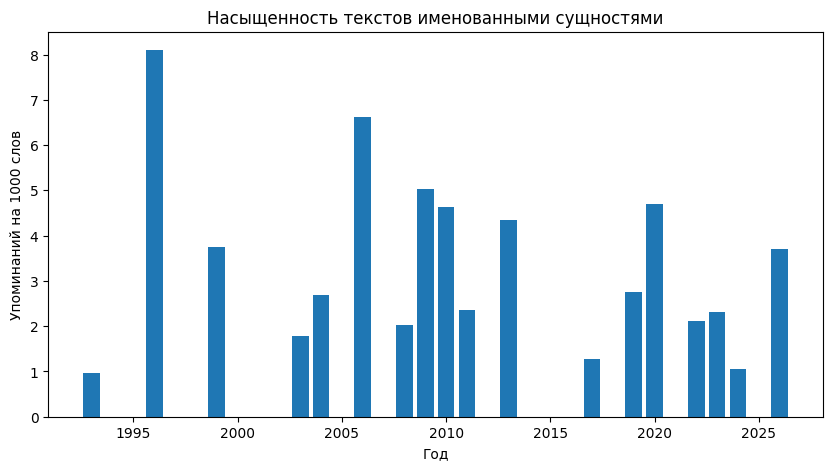

In [95]:
mentions = mentions.sort_values("year")

plt.figure(figsize=(10,5))

plt.bar(
    mentions["year"],
    mentions["mentions_per_1000_words"]
)

plt.xlabel("Год")
plt.ylabel("Упоминаний на 1000 слов")
plt.title("Насыщенность текстов именованными сущностями")

plt.show()

### Страны и регионы

In [96]:
REGIONS = {
    "Россия": {
        "Россия",
        "СССР",
        "РСФСР",
        "Российская империя",
        "Российская республика",
        "Русское царство",
        "Великое княжество Московское",
        "Киевская Русь",
        "Звенигородка",
        "Чечня",
    },

    "Запад": {
        # Британия / англосфера
        "Великобритания",
        "Королевство Великобритания",
        "Королевство Англия",
        "Соединённое королевство Великобритании и Ирландии",
        "США",
        "Канада",
        "Австралия",
        "Ирландия",
        "Королевство Ирландия",

        # Франция
        "Франция",
        "Королевство Франция",

        # Германия / германские государства
        "Германия",
        "Нацистская Германия",
        "Германский рейх",
        "Германская империя",
        "Веймарская республика",
        "Королевство Пруссия",
        "Королевство Бавария",
        "Бавария",
        "Королевство Саксония",
        "курфюршество Саксония",
        "Саксен-Веймар-Эйзенах",
        "Гамбург",
        "Королевство Вюртемберг",
        "Герцогство Вюртемберг",
        "Американская зона оккупации Германии",

        # Италия / итальянские государства
        "Италия",
        "Королевство Италия",
        "Итальянская социальная республика",
        "Флоренция",
        "Ассизи",
        "Флорентийская республика",
        "Флорентийское герцогство",
        "Пармское герцогство",
        "Венецианская республика",
        "castle of the counts of Aquino",

        # Испания / Португалия
        "Испания",
        "Королевство Кастилия и Леон",

        # Нидерланды / Бельгия / Швейцария
        "Королевство Нидерландов",
        "Республика Соединённых провинций",
        "Northern Low Countries",
        "Бельгия",
        "Швейцария",
        "Республика Женева",

        # Австрия / Центральная Европа
        "Австрия",
        "Австро-Венгрия",
        "Австрийская империя",
        "Эрцгерцогство Австрия",
        "Цислейтания",
        "Священная Римская империя",
        "Королевство Богемия",
        "Чехословакия",
        "Словения",

        # Северная Европа
        "Норвегия",
        "Швеция",
        "Исландия",
        "Датское королевство",
    },

    "Античный мир": {
        "Древний Рим",
        "Древние Афины",
        "Греция",
        "Македония",
        "Сиракузы",
        "Стагир",
        "Делос",
        "Элида",
        "Ионийский союз",
        "Кинф",
        "Акрагант",
        "Agyrion",
        "Синоп",
        "Кос",
        "Самос",
        "Эфес",
        "Галикарнас",
        "Фивы",
        "Тиана",
        "Лу",
    },

    "Ближний Восток": {
        "Израильское царство",
        "Северное Израильское царство",
        "Иудейское царство",
        "Иродианская Иудея",
        "Ханаан",
        "Филистия",
        "Магдала",
        "Мекка",
        "Эмеза",
        "Эдем",
        "Турция",
        "Кайсери",
        "Иран",
        "Шираз",
        "Держава Ахеменидов",
        "Парфянское царство",
        "Аббасидский халифат",
        "Византия",
    },

    "Восток / Азия": {
        # Китай
        "Китай",
        "Цинь",
        "Чжоу",
        "царство Сун",
        "империя Тан",
        "империя Юань",
        "империя Цин",
        "Китайская Республика (Тайвань)",

        # Япония
        "Япония",
        "Японская империя",

        # Индия / Южная Азия
        "Индия",
        "Британская Индия",
        "Пакистан",
        "Непал",
        "Лумбини",
        "Видеха",
        "Нанкана-Сахиб",

        # Центральная Азия / империи
        "Самарканд",
        "Монгольская империя",
        "Империя гуннов",

        # прочее
        "Азия",
        "Британский Гонконг",
    },

    "Африка": {
        "Египет",
        "Древний Египет",
        "Хелуан",
        "Гана",
        "Королевство Ливия",
        "Карфаген",
    },

    "Латинская Америка": {
        "Куба",
        "Колумбия",
        "Чили",
        "Мексика",
        "Аргентина",
        "Панама",
        "Ямайка",
    },

    "Украина": {
        "Украинская ССР",
        "Западно-Украинская народная республика",
    },
}


def country_to_region_manual(country):
    if pd.isna(country):
        return np.nan

    country = str(country).strip()

    if country == "":
        return np.nan

    for region, countries in REGIONS.items():
        if country in countries:
            return region

    return "Прочее"

df["region"] = df["страна"].apply(country_to_region_manual)

In [97]:
df.to_csv('result1.csv')

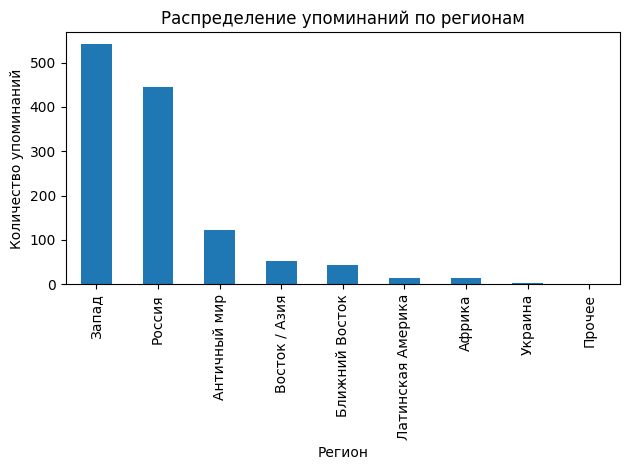

In [98]:
df["region"].value_counts().plot(kind="bar")

plt.xlabel("Регион")
plt.ylabel("Количество упоминаний")
plt.title("Распределение упоминаний по регионам")
plt.tight_layout()
plt.show()

### Динамика отношения запад/Россия

In [99]:
pivot = (
    df.groupby(["year", "region"])["count"]
      .sum()
      .unstack(fill_value=0)
)

pivot.head()

region,Античный мир,Африка,Ближний Восток,Восток / Азия,Запад,Латинская Америка,Прочее,Россия,Украина
year,,,,,,,,,
1993,6,0,10,6,38,1,0,58,0
1996,16,0,0,193,119,0,0,448,0
1999,1,0,3,6,63,14,0,144,1
2003,5,2,1,5,140,0,0,68,0
2004,9,1,0,14,99,9,0,62,0


In [100]:
pivot["west_to_russia"] = pivot["Запад"] / pivot["Россия"]

print(pivot["west_to_russia"])

year
1993     0.655172
1996     0.265625
1999     0.437500
2003     2.058824
2004     1.596774
2006     0.647887
2008     1.615385
2009     0.067010
2010     1.538462
2011    25.222222
2013     0.826087
2016     1.032258
2017     3.238095
2019     1.574468
2020     1.386364
2021     1.444444
2022     0.565217
2023     4.000000
2024     2.428571
2026     9.722222
Name: west_to_russia, dtype: float64


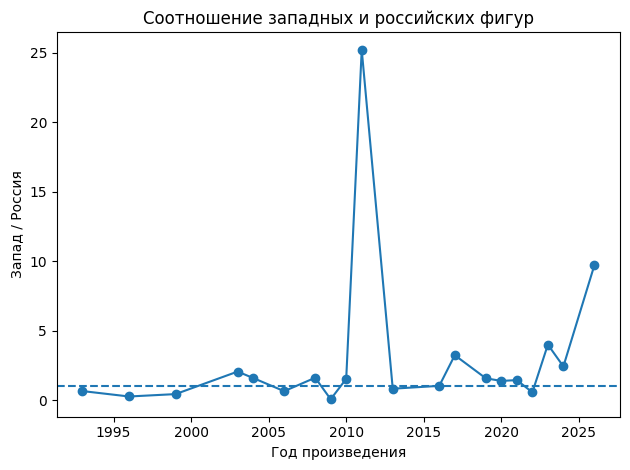

In [101]:
pivot["west_to_russia"].plot(marker="o")

plt.axhline(1, linestyle="--")  # линия равенства

plt.ylabel("Запад / Россия")
plt.xlabel("Год произведения")
plt.title("Соотношение западных и российских фигур")

plt.tight_layout()
plt.show()

### Конкретные сущности

In [116]:
df.columns

Index(['source', 'entity', 'count', 'activities', 'birth_year', 'death_year',
       'страна', 'year', 'region', 'is_character'],
      dtype='object')

In [115]:
characters = pd.DataFrame([
    ["Empire V", "Осирис"],
    ["Empire V", "Гера"],
    ["Бэтман Аполло", "Гера"],
    ["Бэтман Аполло", "Осирис"],
    ["Чапаев и пустота", "Чапаев, Василий Иванович"],
    ["S.N.U.F.F.","Леви, Бернар-Анри"],
    ["t", "Достоевский, Фёдор Михайлович"],
    ["Empire V", "Иштар"],
    ["Бэтман Аполло", "Иштар"],
    ["t","Толстой, Лев Николаевич"],
    ["Непобедимое солнце", "Каракалла"],
    ["Непобедимое солнце", "Гелиогабал"],
    ["Empire V", "Бальдр"],
    ["Ананасная вода для прекрасной дамы","Буш, Джордж (старший)"],
    ["Чапаев и пустота", "Шварценеггер, Арнольд"],
    ["t","Победоносцев, Константин Петрович"],
    ["Ананасная вода для прекрасной дамы","Аристотель"],
    ["Возвращение Синей Бороды", "Эпштейн, Джеффри"],
    ["A Sinistra  А Синистра  Левый Путь","Медичи, Лоренцо"],
    ["Чапаев и пустота","Кавабата, Ясунари"],
    ["Empire V", "Энлиль"],
    ["Бэтман Аполло", "Энлиль"],
    ["Empire V", "Брама"],
    ["Бэтман Аполло", "Брама"],
    ["Непобедимое солнце", "Элагабал (бог)"],
    ["A Sinistra  А Синистра  Левый Путь","Селена"],
    ["Generation «П»", "Березовский, Борис Абрамович"],
    ["Непобедимое солнце", "Марк Лициний Красс"],
    ["S.N.U.F.F.", "Голиаф"],
    ["Empire V", "Мардук"],
    ["Бэтман Аполло", "Мардук"],
    ["Чапаев и пустота", "Брюсов, Валерий Яковлевич"],
    ["Чапаев и пустота", "Унгерн-Штернберг, Роман Фёдорович фон"]
], columns=["source", "entity"])

characters["is_character"] = True

df = df.merge(
    characters,
    on=["source", "entity"],
    how="left"
)

df["is_character"] = df["is_character"].fillna(False)

C:\Users\ivanr\AppData\Local\Temp\ipykernel_19928\103336185.py:45: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["is_character"] = df["is_character"].fillna(False)


In [117]:
import plotly.express as px

filtered_df = df[~df["is_character"]]

agg_df = filtered_df.groupby('entity').agg(
    total_count=('count', 'sum'),
    activities=('activities', 'first'),
    birth_year=('birth_year', 'first'),
    death_year=('death_year', 'first')
).reset_index()

TOP_N = 50

top = agg_df.nlargest(TOP_N, 'total_count').copy()
top = top.sort_values('total_count', ascending=True)

fig = px.bar(
    top,
    x='total_count',
    y='entity',
    orientation='h',
    text='total_count',
    title=f'Топ-{TOP_N} самых частотных персоналий (без персонажей)',
    labels={
        'total_count': 'Суммарное количество упоминаний',
        'entity': ''
    },
    color='total_count',
    color_continuous_scale='Viridis'
)

fig.update_traces(textposition='outside')
fig.update_layout(height=600, width=900)

fig.show()

### Распределение макро-категорий

In [118]:
super_categories = {
    "Литература": [
        "писатель", "писательница", "поэт", "поэтесса",
        "драматург", "переводчик", "сценарист",
        "критик", "публицист", "журналист", "литератор"
    ],

    "Культура": [
        "актёр", "актриса", "режиссёр",
        "музыкант", "певец", "певица",
        "композитор", "художник", "скульптор",
        "архитектор", "живописец", "гравёр"
    ],

    "Наука": [
        "учёный", "историк", "философ",
        "психолог", "социолог", "лингвист"
    ],

    "Политика": [
        "политик", "деятель", "революционер",
        "военачальник", "полководец",
        "правитель", "предводитель",
        "император", "царь"
    ],

    "Другое": [
        "предприниматель", "изобретатель", "инженер",
        "лётчик", "космонавт",
        "спортсмен", "спортсменка"
    ],

    "Религия": [
        "богослов", "священник", "монах",
        "святой", "апостол", "пророк",
        "мистик", "гуру"
    ],

    "Мифология": [
        "бог", "богиня", "божество"
    ]
}

In [119]:
activity_to_category = {}

for category, activities in super_categories.items():
    for activity in activities:
        activity_to_category[activity] = category

In [121]:
def get_super_categories(activities):
    if not isinstance(activities, list):
        return []

    return list({
        activity_to_category[a]
        for a in activities
        if a in activity_to_category
    })


df["super_categories"] = df["activities"].apply(get_super_categories)

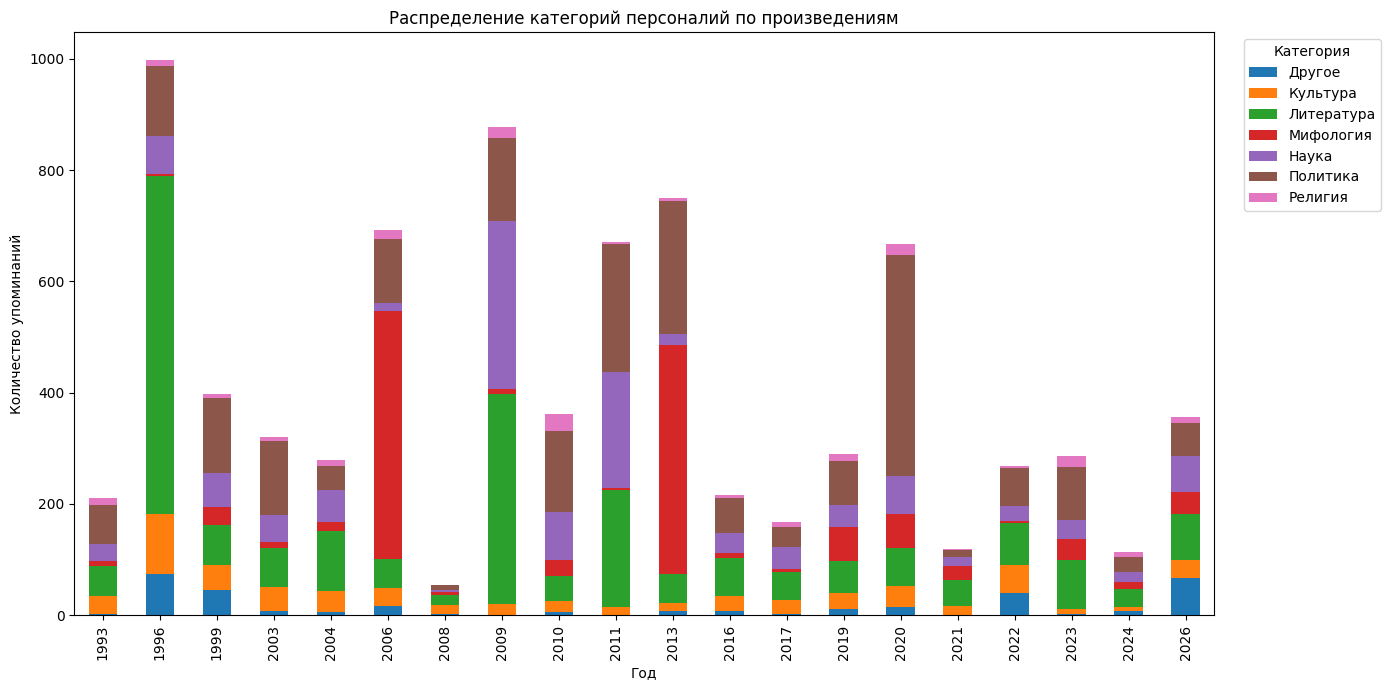

In [126]:
df_exp = df.explode("super_categories")

plot_df = (
    df_exp.groupby(["year", "super_categories"])["count"]
    .sum()
    .unstack(fill_value=0)
    .sort_index()
)

plot_df.plot(
    kind="bar",
    stacked=True,
    figsize=(14, 7)
)

plt.xlabel("Год")
plt.ylabel("Количество упоминаний")
plt.title("Распределение категорий персоналий по произведениям")
plt.legend(title="Категория", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()

plt.show()

In [138]:
df.groupby('source')["year"].first()

source
A Sinistra  А Синистра  Левый Путь                         2023
Empire V                                                   2006
Generation «П»                                             1999
KGBT+ (КГБТ+)                                              2022
S.N.U.F.F.                                                 2011
TRANSHUMANISM INC                                          2021
iPhuck 10                                                  2017
t                                                          2009
Ананасная вода для прекрасной дамы                         2010
Бэтман Аполло                                              2013
Возвращение Синей Бороды                                   2026
Желтая стрела                                              1993
Жизнь насекомых                                            1993
Зал поющих кариатид                                        2008
Искусство легких касаний                                   2019
Круть                            

### Советские

In [140]:
total = (
    df.groupby("year")["count"]
      .sum()
)

ussr = (
    df[df["страна"] == "СССР"]
    .groupby("year")["count"]
    .sum()
)

share = (ussr / total).fillna(0)

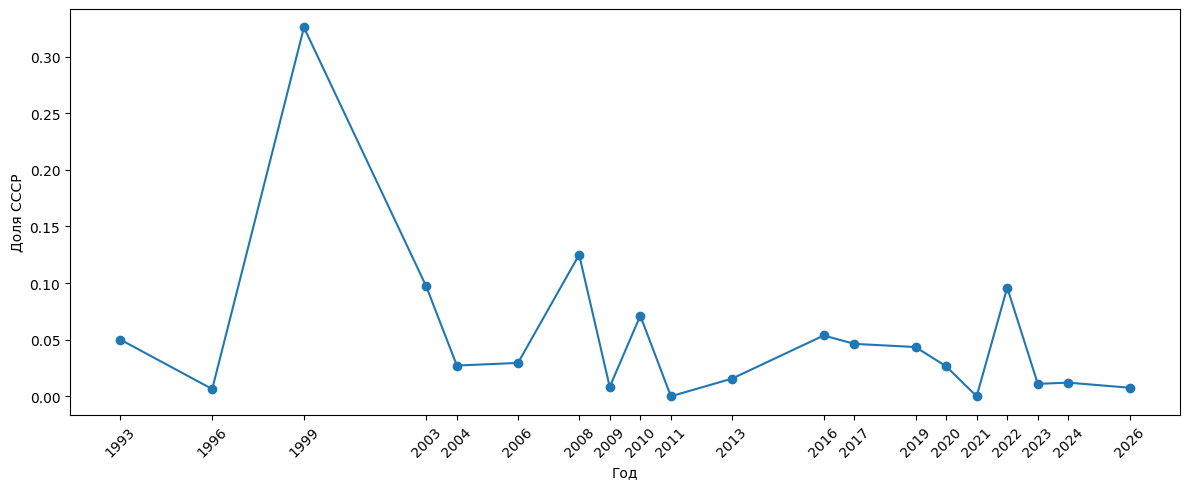

In [144]:
share = share.sort_index()

x = share.index.astype(int)
y = share.values

plt.figure(figsize=(12, 5))

plt.plot(x, y, marker="o")

plt.xticks(x, rotation=45)

plt.xlabel("Год")
plt.ylabel("Доля СССР")

plt.tight_layout()
plt.show()